# Study A Cross-Arm Analysis

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    CROSS_ARM_STUDY_CONFIG,
    load_cross_arm_data,
    plot_cross_arm_heatmap,
    plot_cross_arm_trends,
    plot_main_metric_ci,
    plot_secondary_delta_ci,
    secondary_missing_table,
    secondary_threshold_audit,
    find_runtime_root,
    setup_notebook_style,
    summarise_cross_arm_effects,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results"
study = "study_a"
main_metrics = ['faithfulness_gap', 'step_f1', 'acc_cot', 'acc_early']
headline_metric = "faithfulness_gap"
main_long, secondary, coverage = load_cross_arm_data(
    metric_root=metric_root,
    runtime_root=runtime_root,
    study=study,
)
secondary_summary = summarise_cross_arm_effects(secondary)
print("Runtime root:", runtime_root)
print("Main rows:", len(main_long), "Secondary rows:", len(secondary), "Coverage rows:", len(coverage))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Main rows: 20 Secondary rows: 76 Coverage rows: 18


## Provenance and coverage

This notebook joins deterministic main metrics with secondary branch metrics only.
Pairwise judge outputs are intentionally excluded. Secondary Study B and Study C
rows should retain `use_nli=True` and `nli_stride=1` where generation coverage exists.

In [2]:
coverage_display = coverage[["lane", "model", "study", "status", "use_nli", "nli_stride", "data_root"]].copy()
display(coverage_display.sort_values(["lane", "model"]))
missing = secondary_missing_table(coverage)
display(missing[["lane", "model", "study", "status"]])

,lane,model,study,status,use_nli,nli_stride,data_root
0,controllability,deepseek-r1-lmstudio,study_a,missing_cache,NaN,NaN,NaN
15,controllability,gpt-oss-20b,study_a,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
5,controllability,piaget-8b-local,study_a,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
20,controllability,psyche-r1-local,study_a,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
25,controllability,psyllm-lmstudio,study_a,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
10,controllability,qwen3-lmstudio,study_a,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
60,ctrl-invariance,deepseek-r1-lmstudio,study_a,missing_cache,NaN,NaN,NaN
75,ctrl-invariance,gpt-oss-20b,study_a,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
65,ctrl-invariance,piaget-8b-local,study_a,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
80,ctrl-invariance,psyche-r1-local,study_a,missing_cache,NaN,NaN,NaN


,lane,model,study,status
0,controllability,deepseek-r1-lmstudio,study_a,missing_cache
1,ctrl-invariance,deepseek-r1-lmstudio,study_a,missing_cache
2,ctrl-invariance,psyche-r1-local,study_a,missing_cache
3,invariance,deepseek-r1-lmstudio,study_a,missing_cache


## Main performance

,model,study,arm,metric,value,ci_low,ci_high,n
2,deepseek-r1-lmstudio,study_a,main,acc_cot,0.0111,0.0071,0.0156,1981.0
6,gpt-oss-20b,study_a,main,acc_cot,0.0320,0.0240,0.0390,1999.0
18,piaget-8b-local,study_a,main,acc_cot,0.0356,0.0275,0.0438,1964.0
14,psyche-r1-local,study_a,main,acc_cot,0.0840,0.0720,0.0965,2000.0
10,qwen3-lmstudio,study_a,main,acc_cot,0.0155,0.0105,0.0205,1998.0
3,deepseek-r1-lmstudio,study_a,main,acc_early,0.2135,0.1969,0.2302,1981.0
7,gpt-oss-20b,study_a,main,acc_early,0.2341,0.2156,0.2536,1999.0
19,piaget-8b-local,study_a,main,acc_early,0.1415,0.1263,0.1568,1964.0
15,psyche-r1-local,study_a,main,acc_early,0.1660,0.1510,0.1815,2000.0
11,qwen3-lmstudio,study_a,main,acc_early,0.2818,0.2628,0.3008,1998.0


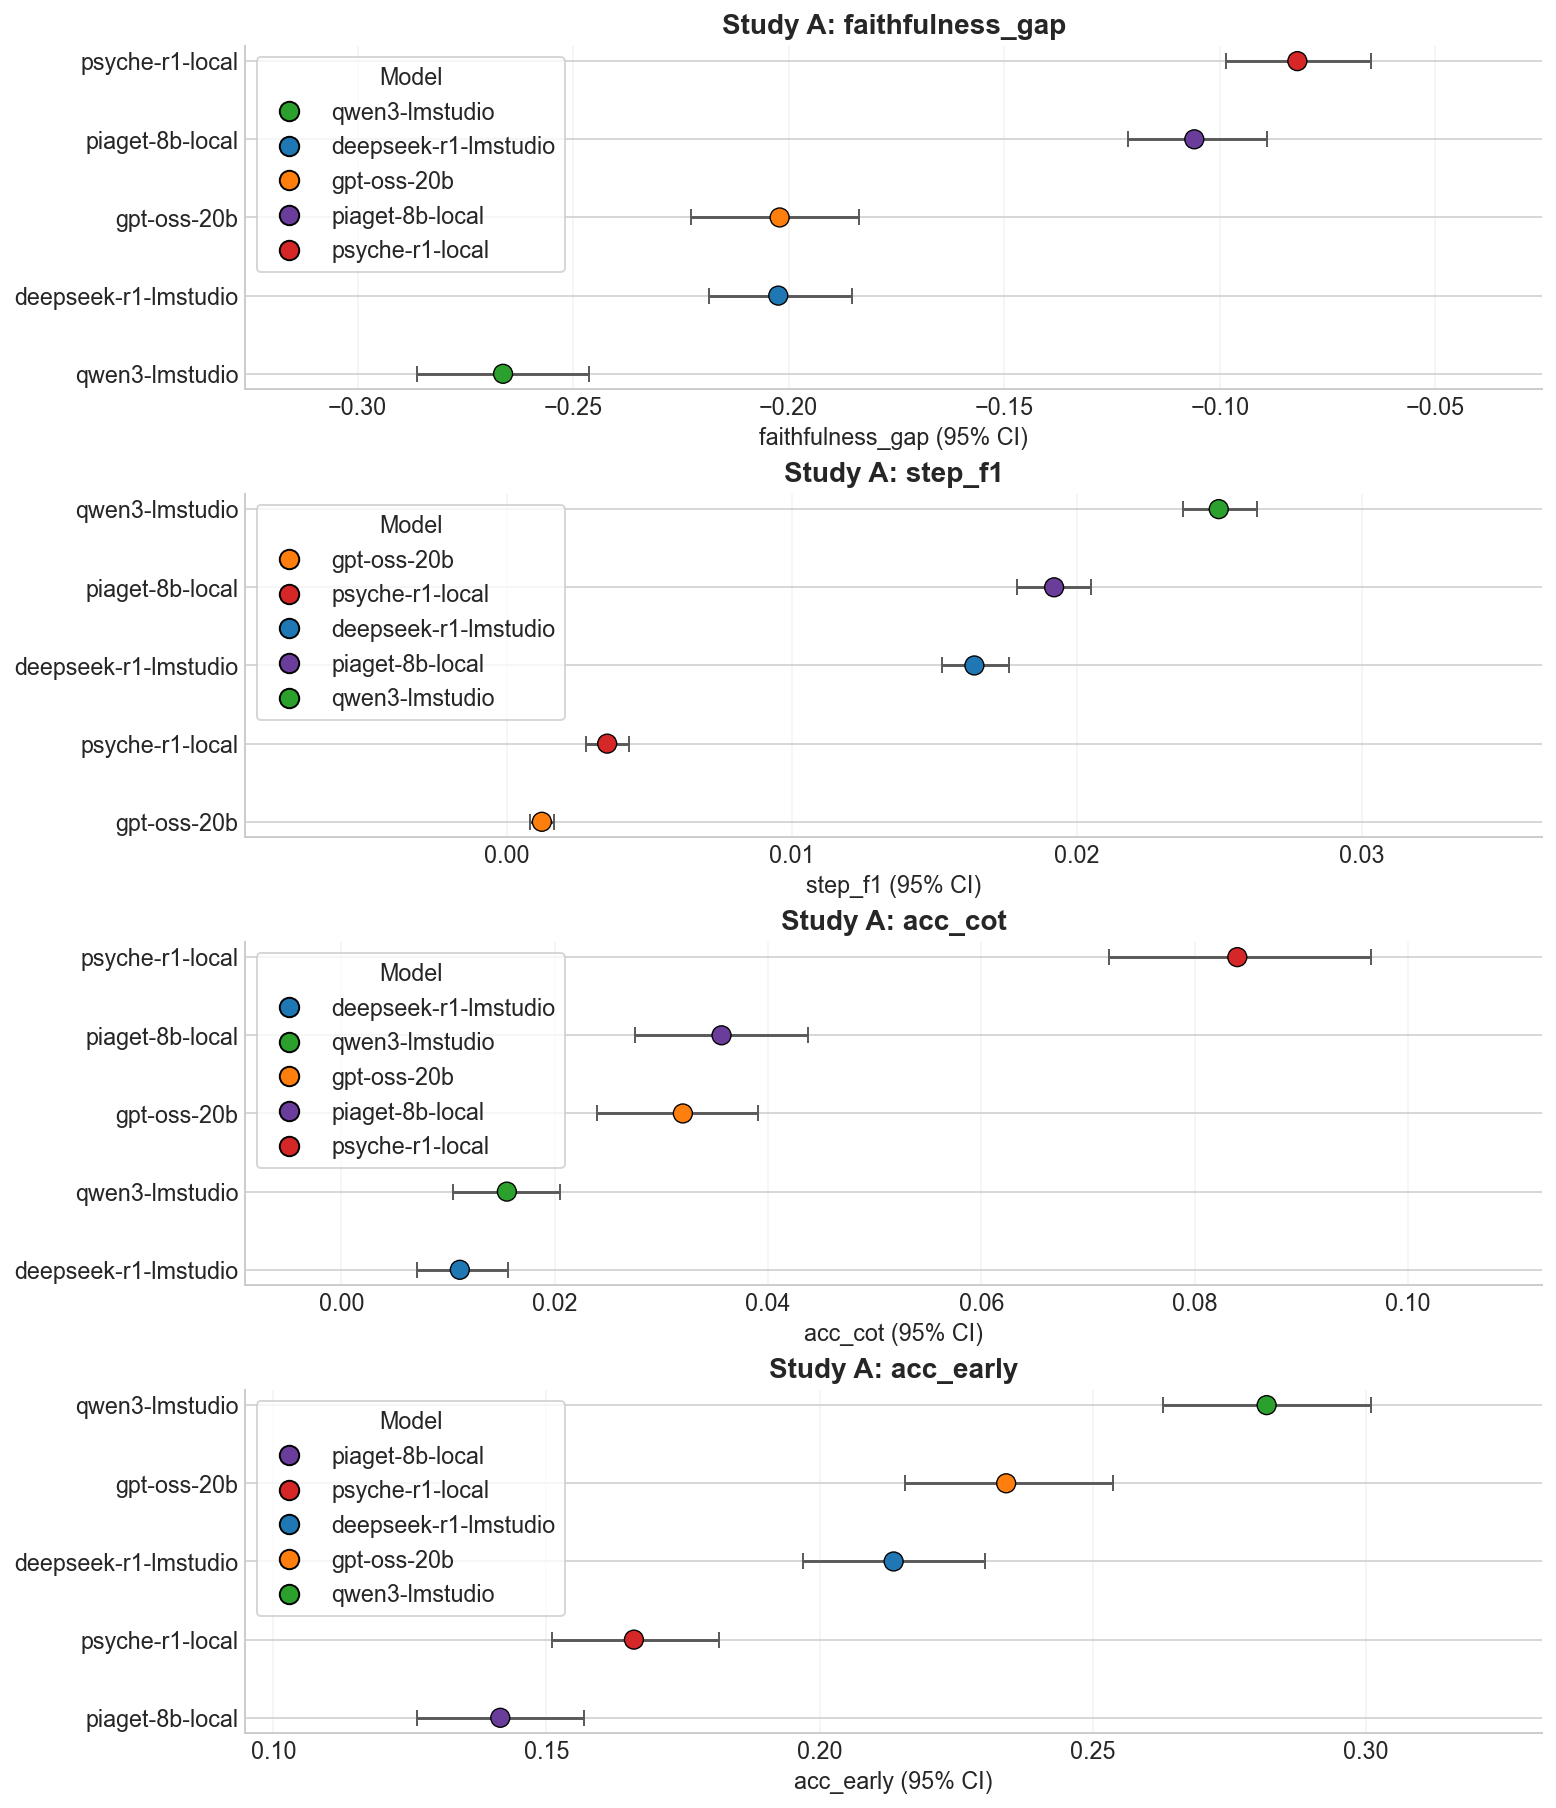

In [3]:
main_table = main_long.sort_values(["metric", "model"]).copy()
display(main_table.round(4))

fig, axes = plt.subplots(
    len(main_metrics),
    1,
    figsize=(11, max(4, 3.2 * len(main_metrics))),
    constrained_layout=True,
)
if len(main_metrics) == 1:
    axes = [axes]
for ax, metric in zip(axes, main_metrics):
    plot_main_metric_ci(
        main_long,
        ax=ax,
        metric=metric,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {metric}",
    )
plt.show()

## Controllability

The zero line is the no-effect threshold. Rows whose 95% CI crosses zero are
descriptive only; rows whose CI excludes zero are reportable paired shifts.

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,controllability,piaget-8b-local,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,controllability,psyche-r1-local,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_a,generic_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
9,controllability,qwen3-lmstudio,study_a,explicit_control,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


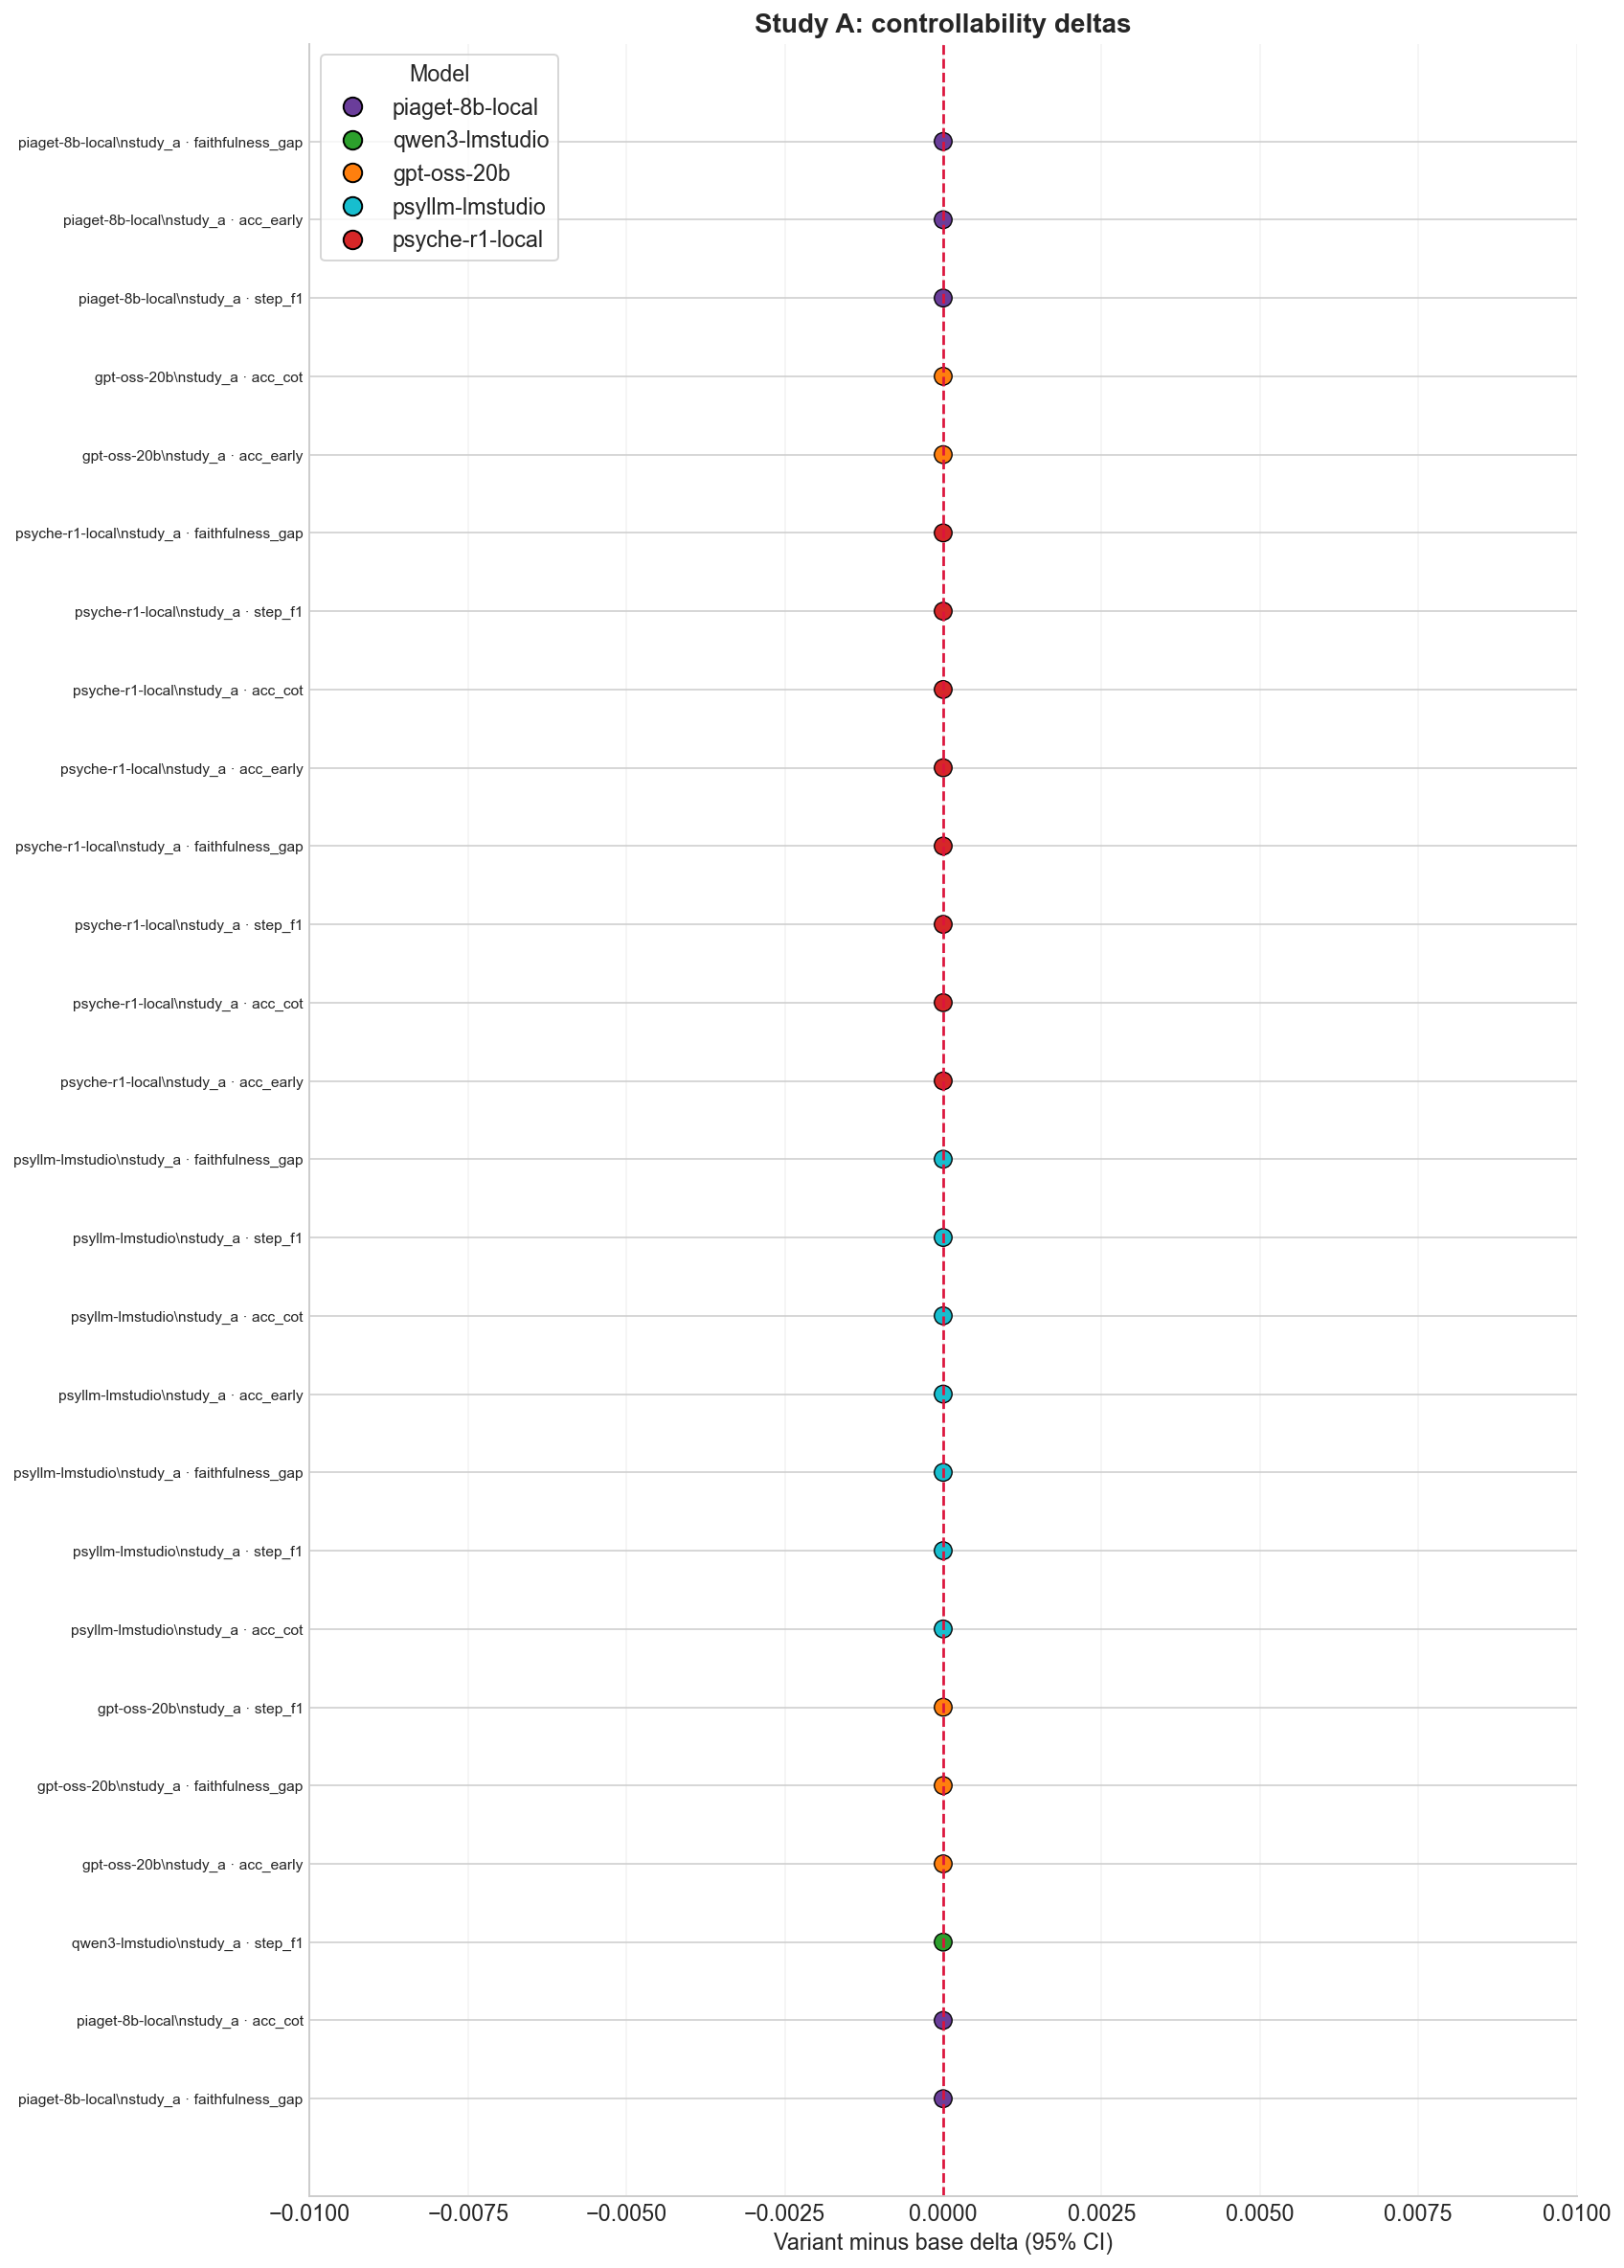

In [4]:
ctrl = secondary[secondary["lane"] == "controllability"].copy()
display(secondary_threshold_audit(ctrl).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(ctrl), 8))), constrained_layout=True)
plot_secondary_delta_ci(ctrl, ax=ax, title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: controllability deltas", max_rows=26)
plt.show()

## Invariance and ctrl-invariance

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_a,invariance_variant,acc_cot,150,0.0200,0.0133,-0.0067,-0.0333,0.0200,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_a,invariance_variant,acc_cot,145,0.0345,0.0483,0.0138,-0.0276,0.0552,CI overlaps zero; descriptive only
2,invariance,psyche-r1-local,study_a,invariance_variant,acc_cot,150,0.0933,0.0733,-0.0200,-0.0800,0.0333,CI overlaps zero; descriptive only
3,invariance,psyllm-lmstudio,study_a,invariance_variant,acc_cot,98,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
4,invariance,qwen3-lmstudio,study_a,invariance_variant,acc_cot,149,0.0000,0.0067,0.0067,0.0000,0.0201,CI overlaps zero; descriptive only
5,invariance,gpt-oss-20b,study_a,invariance_variant,acc_early,150,0.1667,0.1867,0.0200,-0.0400,0.0800,CI overlaps zero; descriptive only
6,invariance,piaget-8b-local,study_a,invariance_variant,acc_early,145,0.0828,0.1379,0.0552,-0.0069,0.1241,CI overlaps zero; descriptive only
7,invariance,psyche-r1-local,study_a,invariance_variant,acc_early,150,0.2000,0.1667,-0.0333,-0.0800,0.0067,CI overlaps zero; descriptive only
8,invariance,psyllm-lmstudio,study_a,invariance_variant,acc_early,98,0.0816,0.1633,0.0816,-0.0102,0.1633,CI overlaps zero; descriptive only
9,invariance,qwen3-lmstudio,study_a,invariance_variant,acc_early,149,0.2215,0.2416,0.0201,-0.0403,0.0872,CI overlaps zero; descriptive only


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,ctrl-invariance,gpt-oss-20b,study_a,ctrl_invariance_variant,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,ctrl-invariance,piaget-8b-local,study_a,ctrl_invariance_variant,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
2,ctrl-invariance,psyllm-lmstudio,study_a,ctrl_invariance_variant,acc_cot,102,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,ctrl-invariance,qwen3-lmstudio,study_a,ctrl_invariance_variant,acc_cot,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,ctrl-invariance,gpt-oss-20b,study_a,ctrl_invariance_variant,acc_early,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
5,ctrl-invariance,piaget-8b-local,study_a,ctrl_invariance_variant,acc_early,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
6,ctrl-invariance,psyllm-lmstudio,study_a,ctrl_invariance_variant,acc_early,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
7,ctrl-invariance,qwen3-lmstudio,study_a,ctrl_invariance_variant,acc_early,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
8,ctrl-invariance,gpt-oss-20b,study_a,ctrl_invariance_variant,faithfulness_gap,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
9,ctrl-invariance,piaget-8b-local,study_a,ctrl_invariance_variant,faithfulness_gap,0,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


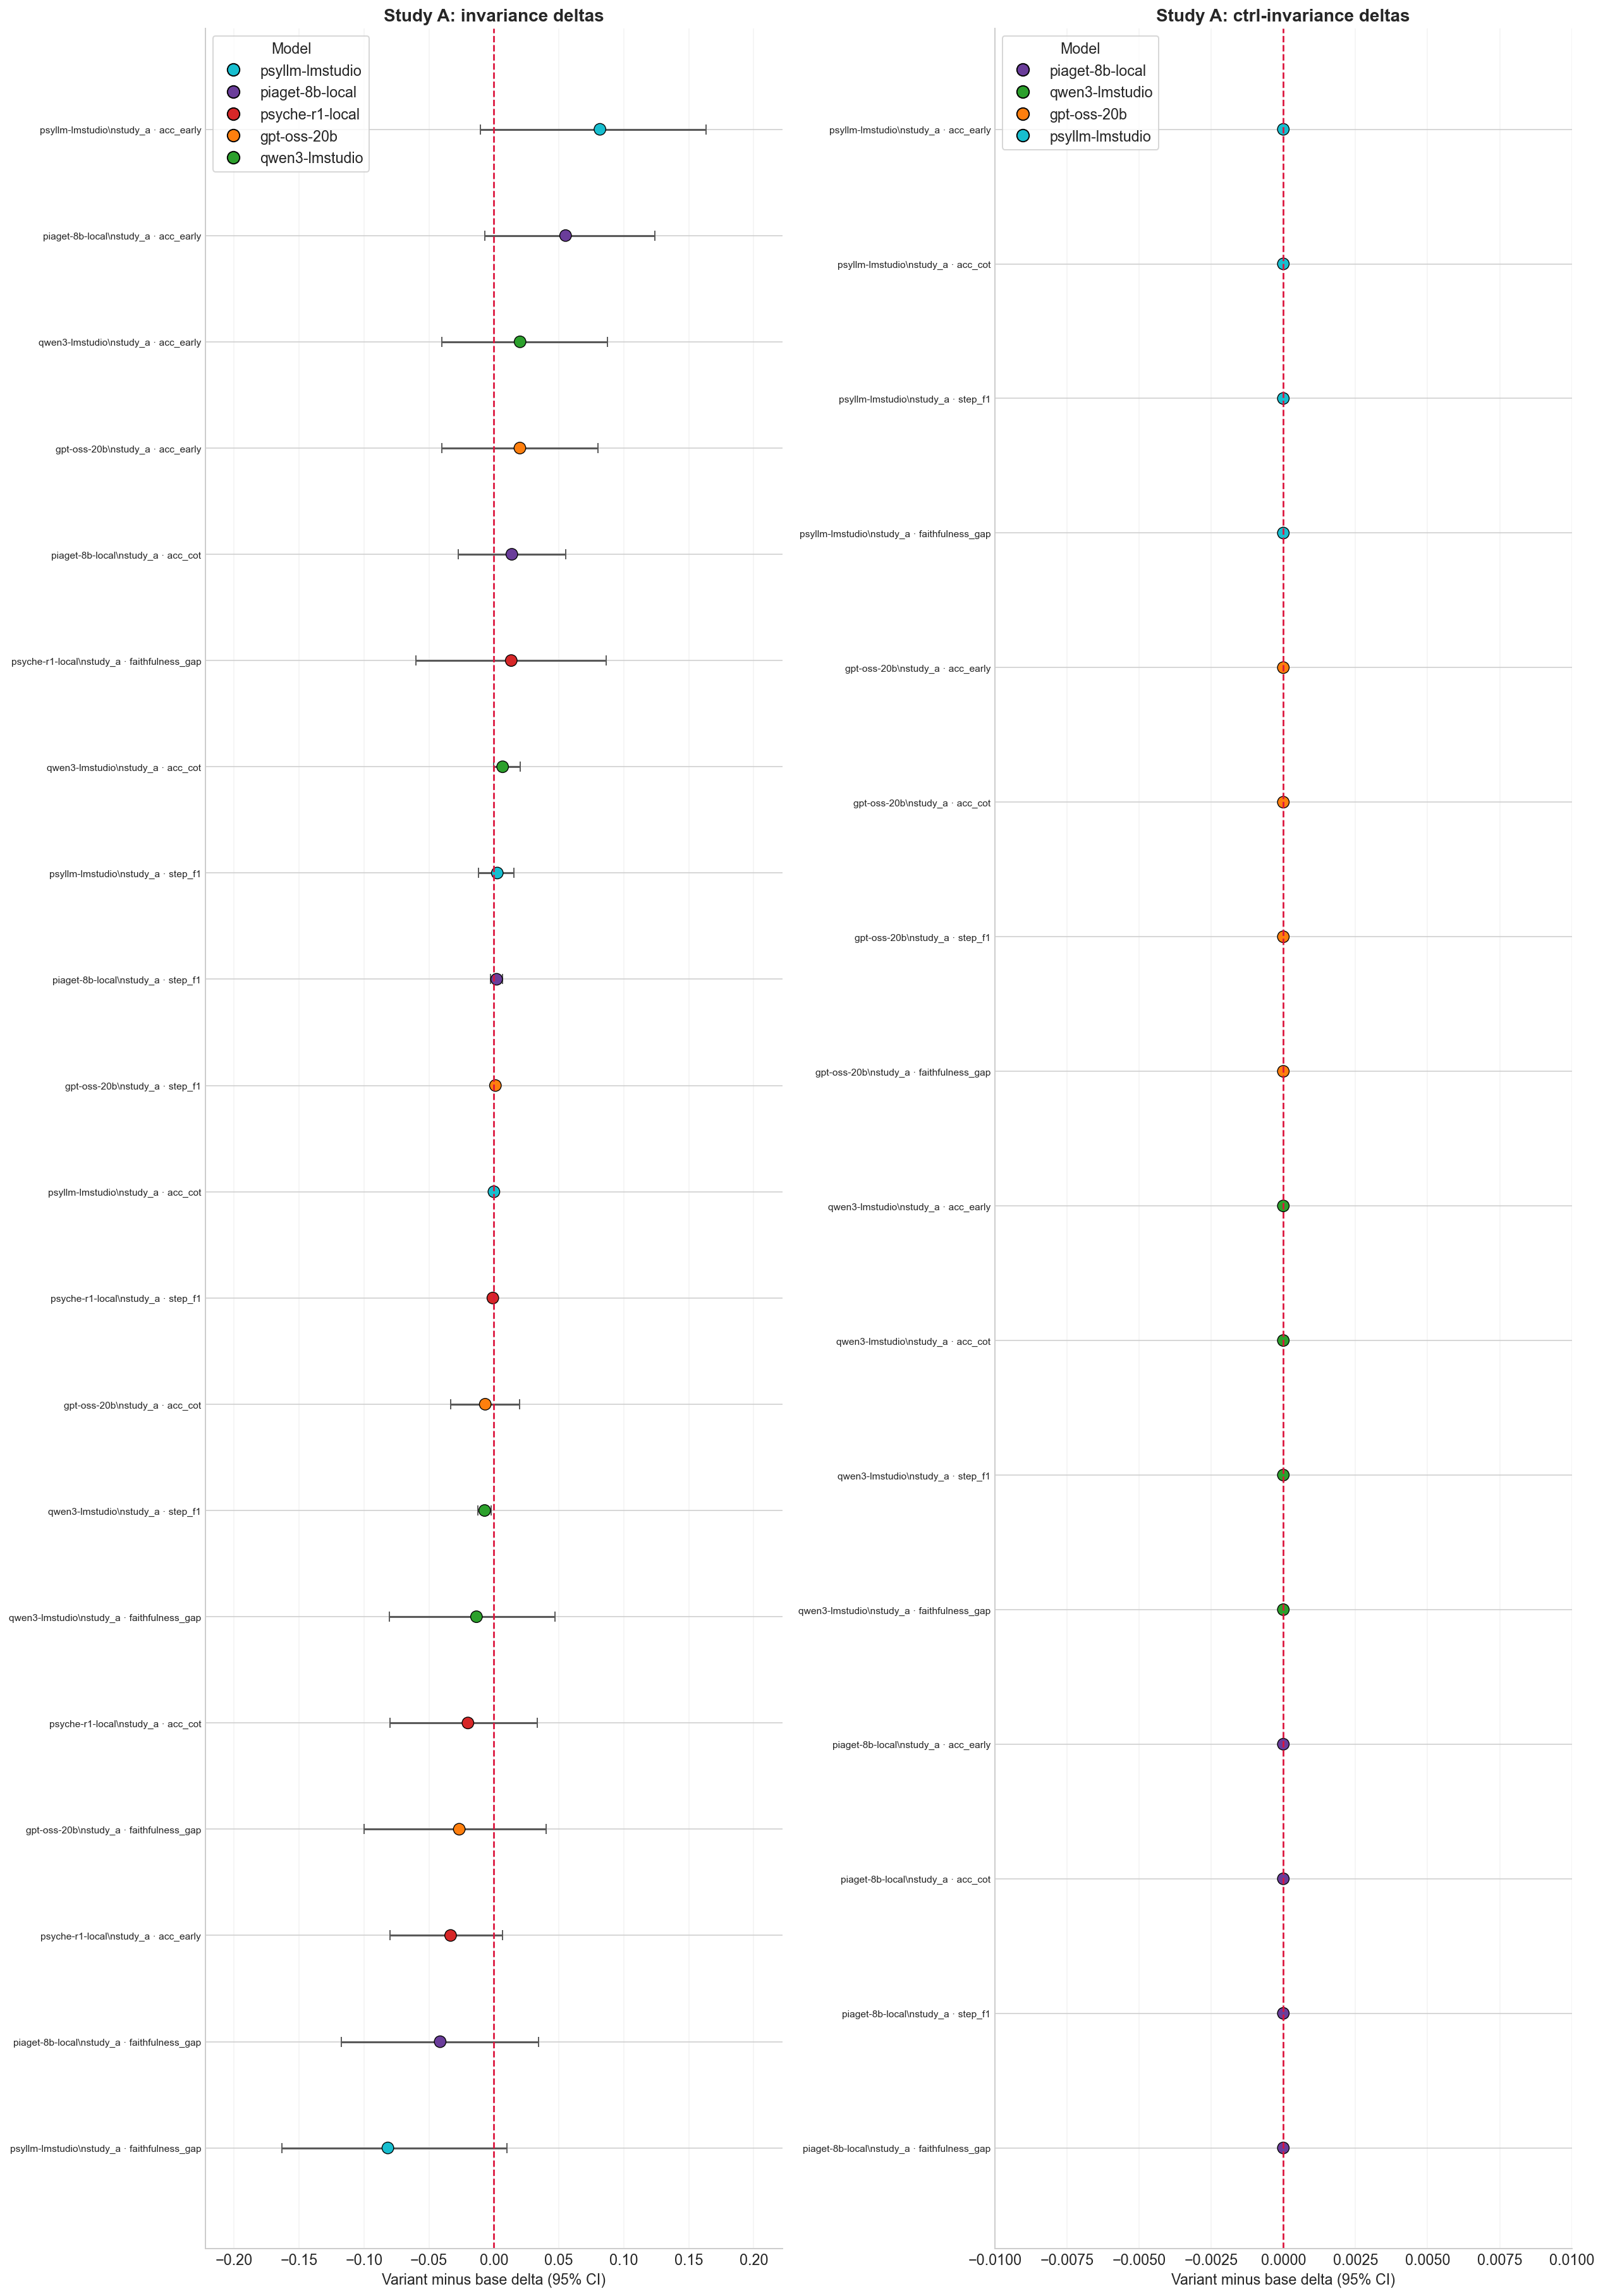

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.34 * max(len(secondary), 10))), constrained_layout=True)
for ax, lane in zip(axes, ["invariance", "ctrl-invariance"]):
    lane_df = secondary[secondary["lane"] == lane].copy()
    display(secondary_threshold_audit(lane_df).round(4))
    plot_secondary_delta_ci(
        lane_df,
        ax=ax,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {lane} deltas",
        max_rows=22,
    )
plt.show()

## Cross-arm trend view

,model,lane,metric_rows,metrics,median_delta,median_abs_delta,max_abs_delta,reportable_rows,descriptive_rows
0,gpt-oss-20b,controllability,8,4,0.0000,0.0000,0.0000,0,8
3,piaget-8b-local,controllability,8,4,0.0000,0.0000,0.0000,0,8
6,psyche-r1-local,controllability,8,4,0.0000,0.0000,0.0000,0,8
8,psyllm-lmstudio,controllability,8,4,0.0000,0.0000,0.0000,0,8
11,qwen3-lmstudio,controllability,8,4,0.0000,0.0000,0.0000,0,8
1,gpt-oss-20b,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
4,piaget-8b-local,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
9,psyllm-lmstudio,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
12,qwen3-lmstudio,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
10,psyllm-lmstudio,invariance,4,4,0.0013,0.0421,0.0816,0,4


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


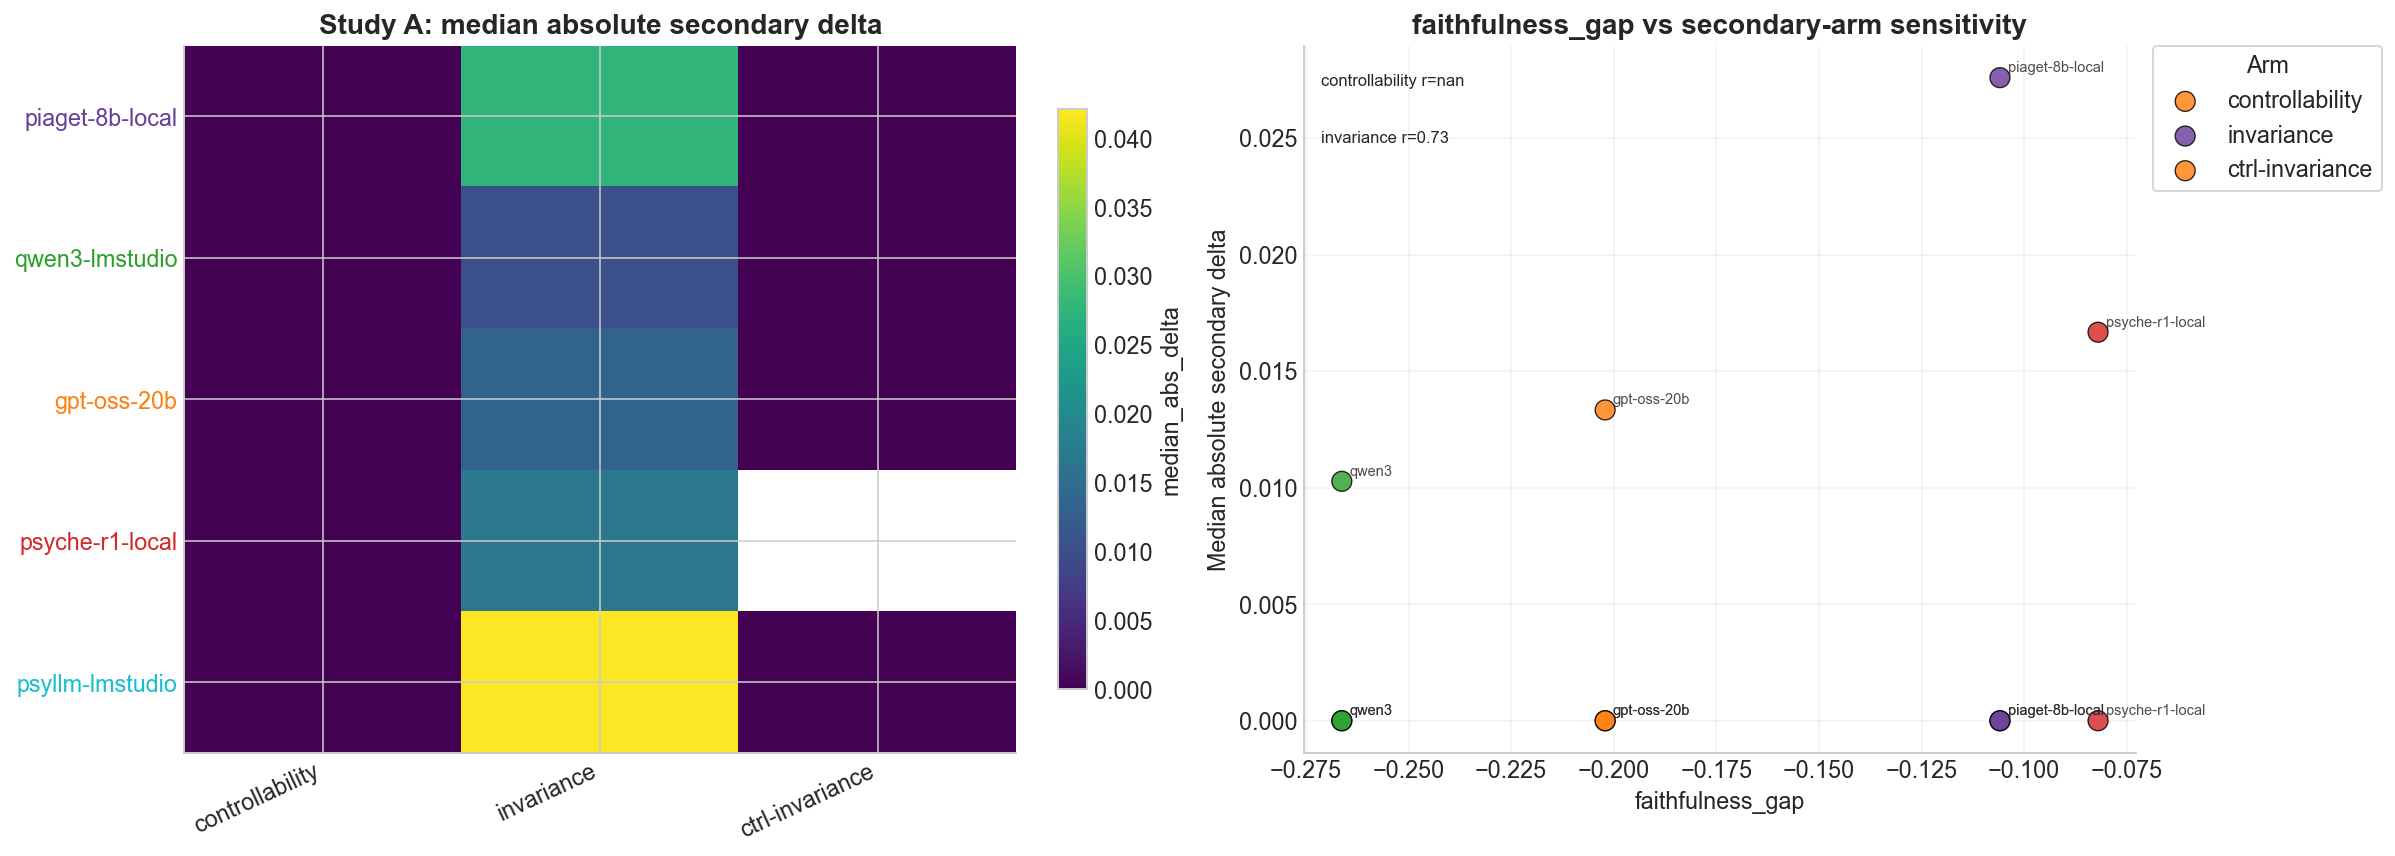

In [6]:
display(secondary_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
plot_cross_arm_heatmap(
    secondary_summary,
    ax=axes[0],
    title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: median absolute secondary delta",
)
plot_cross_arm_trends(
    main_long,
    secondary_summary,
    main_metric=headline_metric,
    ax=axes[1],
    title=f"{headline_metric} vs secondary-arm sensitivity",
)
plt.show()

## Interpretation

Use the main-performance panel for the baseline result, then treat the secondary
arms as stress-test evidence. Controllability reflects responsiveness to explicit
control. Invariance reflects robustness under harmless perturbation. Ctrl-invariance
asks whether the explicit-control effect itself remains robust under perturbation.
Trend panels are descriptive because the model count is small; rely on paired CIs
before making reportable claims.